In [1]:
# ============================================
# 1. Import libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Hiển thị đầy đủ cột
pd.set_option("display.max_columns", None)

In [2]:
# ============================================
# 2. Load raw data
# ============================================

train_df = pd.read_csv("../data/raw/raw_data_train.csv")
test_df = pd.read_csv("../data/raw/raw_data_test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (240000, 19)
Test shape: (60000, 19)


In [3]:
# ============================================
# 3. Chọn các cột cần sử dụng
# ============================================

selected_columns = [
    "price",
    "area",
    "province_name",
    "district_name",
    "ward_name",
    "floor_count",
    "frontage_width",
    "bedroom_count",
    "bathroom_count",
    "house_direction"
]

train_df = train_df[selected_columns]
test_df = test_df[selected_columns]

print("\nSelected columns:")
print(train_df.columns)


Selected columns:
Index(['price', 'area', 'province_name', 'district_name', 'ward_name',
       'floor_count', 'frontage_width', 'bedroom_count', 'bathroom_count',
       'house_direction'],
      dtype='str')


In [4]:
# ============================================
# 4. Kiểm tra missing values
# ============================================

print("\nMissing values in train data:")
print(train_df.isnull().sum())

print("\nMissing values in test data:")
print(test_df.isnull().sum())


Missing values in train data:
price               10460
area                    0
province_name           0
district_name        2729
ward_name           25675
floor_count        140961
frontage_width      93612
bedroom_count       83735
bathroom_count      96853
house_direction    195360
dtype: int64

Missing values in test data:
price               2590
area                   0
province_name          0
district_name        693
ward_name           6493
floor_count        35170
frontage_width     23366
bedroom_count      20939
bathroom_count     24164
house_direction    48906
dtype: int64


In [5]:
# ============================================
# 5. Xóa các dòng bị thiếu giá
# Target column không được null
# ============================================

train_df = train_df.dropna(subset=["price"])
test_df = test_df.dropna(subset=["price"])

print("\nAfter dropping missing price:")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


After dropping missing price:
Train shape: (229540, 10)
Test shape: (57410, 10)


In [6]:
# ============================================
# 6. Xử lý missing values cho numeric columns
# Dùng median vì dữ liệu bất động sản có outlier
# ============================================

numeric_cols = [
    "floor_count",
    "frontage_width",
    "bedroom_count",
    "bathroom_count"
]

for col in numeric_cols:
    median_value = train_df[col].median()

    train_df[col] = train_df[col].fillna(median_value)
    test_df[col] = test_df[col].fillna(median_value)

print("\nMissing values after numeric filling:")
print(train_df[numeric_cols].isnull().sum())


Missing values after numeric filling:
floor_count       0
frontage_width    0
bedroom_count     0
bathroom_count    0
dtype: int64


In [7]:
# ============================================
# 7. Xử lý missing values cho categorical columns
# ============================================

# --------------------------------------------
# 7.1 Fill district_name bằng province + ward
# --------------------------------------------

mapping = (
    train_df
    .dropna(subset=["district_name", "ward_name"])
    .groupby(["province_name", "ward_name"])["district_name"]
    .agg(lambda x: x.mode()[0])
)

def fill_district(row):
    if pd.isna(row["district_name"]):
        key = (row["province_name"], row["ward_name"])

        if key in mapping:
            return mapping[key]

    return row["district_name"]

train_df["district_name"] = train_df.apply(
    fill_district,
    axis=1
)

test_df["district_name"] = test_df.apply(
    fill_district,
    axis=1
)

# --------------------------------------------
# 7.2 Fill các categorical columns còn lại
# --------------------------------------------

categorical_cols = [
    "district_name",
    "ward_name",
    "house_direction"
]

for col in categorical_cols:
    train_df[col] = train_df[col].fillna("Unknown")
    test_df[col] = test_df[col].fillna("Unknown")

print("\nMissing values after categorical filling:")
print(train_df[categorical_cols].isnull().sum())


Missing values after categorical filling:
district_name      0
ward_name          0
house_direction    0
dtype: int64


In [8]:
# ============================================
# 8. Xóa duplicate rows
# ============================================

print("\nBefore removing duplicates:")
print("Train:", train_df.shape)
print("Test:", test_df.shape)

train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()

print("\nAfter removing duplicates:")
print("Train:", train_df.shape)
print("Test:", test_df.shape)


Before removing duplicates:
Train: (229540, 10)
Test: (57410, 10)

After removing duplicates:
Train: (217443, 10)
Test: (56502, 10)


In [9]:
# ============================================
# 9. Xử lý outliers cho price
# Giữ dữ liệu từ 1% đến 99%
# ============================================

print("\nBefore removing price outliers:")
print("Train:", train_df.shape)
print("Test:", test_df.shape)


q1 = train_df["price"].quantile(0.01)
q99 = train_df["price"].quantile(0.99)

train_df = train_df[
    (train_df["price"] >= q1) &
    (train_df["price"] <= q99)
]

print("\nAfter removing outliers:")
print("Train shape:", train_df.shape)


Before removing price outliers:
Train: (217443, 10)
Test: (56502, 10)

After removing outliers:
Train shape: (213267, 10)


In [10]:
# ============================================
# 10. Xử lý outliers cho area
# ============================================

print("\nBefore removing area outliers:")
print("Train:", train_df.shape)
print("Test:", test_df.shape)

q1_area = train_df["area"].quantile(0.01)
q99_area = train_df["area"].quantile(0.99)

train_df = train_df[
    (train_df["area"] >= q1_area) &
    (train_df["area"] <= q99_area)
]

print("\nAfter removing area outliers:")
print("Train shape:", train_df.shape)




Before removing area outliers:
Train: (213267, 10)
Test: (56502, 10)

After removing area outliers:
Train shape: (209352, 10)



Price transformed using log1p


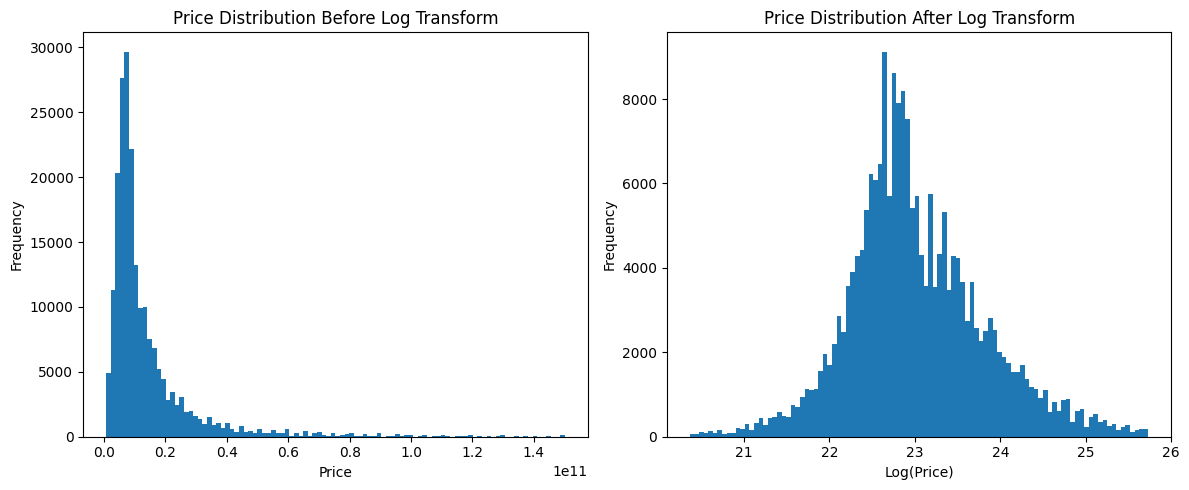

In [11]:
# ============================================
# 11. Log transform target
# Hiển thị phân phối trước và sau log transform
# ============================================

# Backup dữ liệu gốc trước khi transform
original_price = train_df["price"].copy()

# --------------------------------------------
# Vẽ phân phối trước khi log transform
# --------------------------------------------

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.hist(original_price, bins=100)

plt.title("Price Distribution Before Log Transform")
plt.xlabel("Price")
plt.ylabel("Frequency")

# --------------------------------------------
# Log transform
# --------------------------------------------

train_df["price"] = np.log1p(train_df["price"])
test_df["price"] = np.log1p(test_df["price"])

# --------------------------------------------
# Vẽ phân phối sau khi log transform
# --------------------------------------------

plt.subplot(1, 2, 2)

plt.hist(train_df["price"], bins=100)

plt.title("Price Distribution After Log Transform")
plt.xlabel("Log(Price)")
plt.ylabel("Frequency")

# --------------------------------------------
# Hiển thị biểu đồ
# --------------------------------------------

print("\nPrice transformed using log1p")
plt.tight_layout()
plt.show()



In [12]:
# ============================================
# 12. Reset index
# ============================================

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [13]:
# ============================================
# 13. Kiểm tra dữ liệu sau cleaning
# ============================================

print("\nTrain info:")
print(train_df.info())

print("\nTest info:")
print(test_df.info())

print("\nTrain describe:")
print(train_df.describe())


Train info:
<class 'pandas.DataFrame'>
RangeIndex: 209352 entries, 0 to 209351
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   price            209352 non-null  float64
 1   area             209352 non-null  float64
 2   province_name    209352 non-null  str    
 3   district_name    209352 non-null  str    
 4   ward_name        209352 non-null  str    
 5   floor_count      209352 non-null  float64
 6   frontage_width   209352 non-null  float64
 7   bedroom_count    209352 non-null  float64
 8   bathroom_count   209352 non-null  float64
 9   house_direction  209352 non-null  str    
dtypes: float64(6), str(4)
memory usage: 23.6 MB
None

Test info:
<class 'pandas.DataFrame'>
RangeIndex: 56502 entries, 0 to 56501
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   price            56502 non-null  float64
 1   area            

In [14]:
# ============================================
# 14. Kiểm tra missing values cuối cùng
# ============================================

print("\nFinal missing values in train:")
print(train_df.isnull().sum())

print("\nFinal missing values in test:")
print(test_df.isnull().sum())


Final missing values in train:
price              0
area               0
province_name      0
district_name      0
ward_name          0
floor_count        0
frontage_width     0
bedroom_count      0
bathroom_count     0
house_direction    0
dtype: int64

Final missing values in test:
price              0
area               0
province_name      0
district_name      0
ward_name          0
floor_count        0
frontage_width     0
bedroom_count      0
bathroom_count     0
house_direction    0
dtype: int64


In [15]:
# ============================================
# 15. Save clean data
# ============================================

train_df.to_csv(
    "../data/clean/clean_data_train.csv",
    index=False
)

test_df.to_csv(
    "../data/clean/clean_data_test.csv",
    index=False
)

print("\nCleaned data saved successfully!")


Cleaned data saved successfully!


In [16]:
# ============================================
# 16. Final shapes
# ============================================

print("\nFinal dataset shapes:")
print("Train:", train_df.shape)
print("Test:", test_df.shape)


Final dataset shapes:
Train: (209352, 10)
Test: (56502, 10)
